In [28]:
import numpy as np
import pandas as pd

In [29]:
df = pd.read_csv("/run/media/darshchouhan/New Volume/ML-Algorithm/Iris.csv")

In [30]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le = LabelEncoder()

In [33]:
species = le.fit_transform(df['Species'])

In [34]:
df['Species'] = species

In [35]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [36]:
df = df.drop('Id',axis=1)

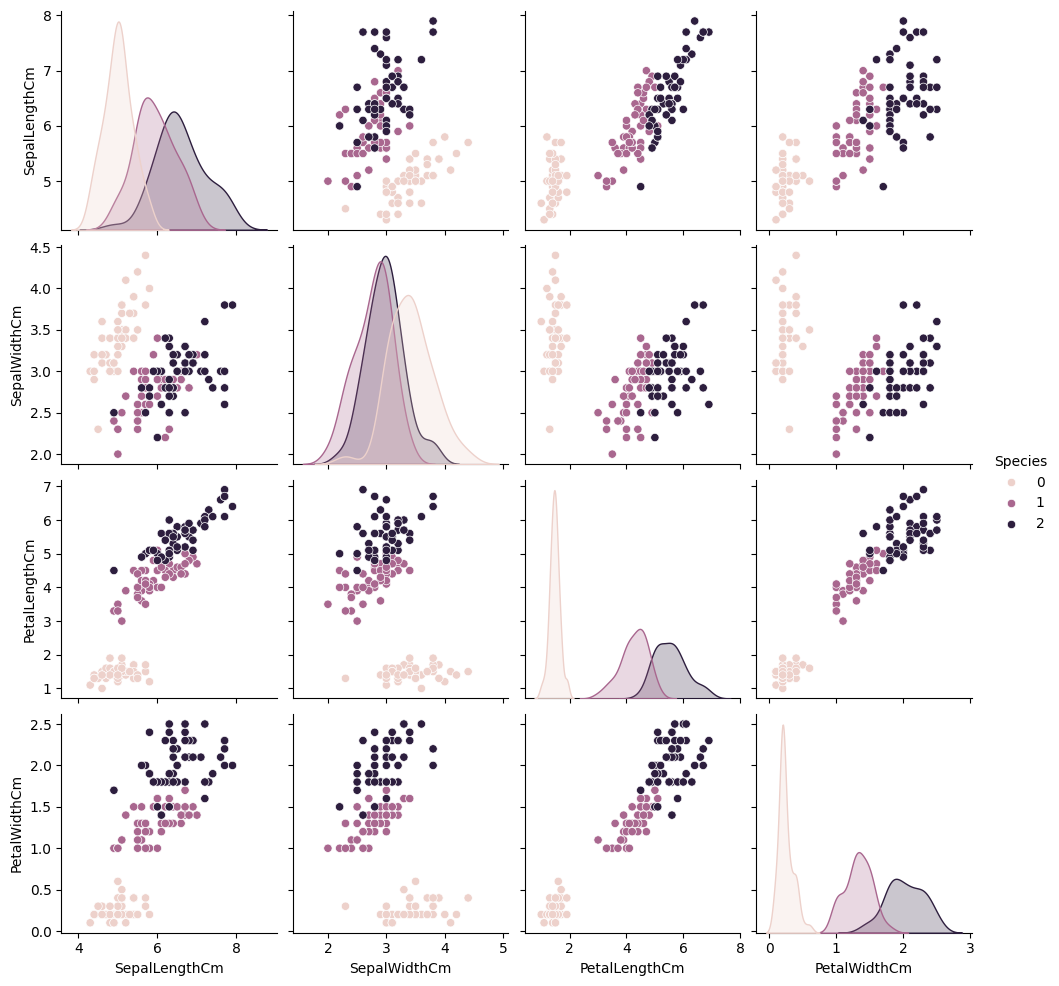

In [37]:
import seaborn as sns
sns.pairplot(df,hue='Species')

In [38]:

new_df = df[df['Species'] != 0][['SepalLengthCm','SepalWidthCm','Species']]

In [39]:
X =  new_df.drop('Species',axis=1)
y = new_df['Species']

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


In [41]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = RandomForestClassifier()

In [42]:
estimators =  [('lr', clf1),('rf',clf2),('knn',clf3)]

In [43]:
X.shape


(100, 2)

In [44]:
y.shape

(100,)

In [46]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.75
rf 0.61
knn 0.6


### Hard Voting

In [52]:
from sklearn.ensemble import VotingClassifier
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=20,scoring='accuracy')
print(np.mean(x))

0.66


## Soft Voting

In [53]:
from sklearn.ensemble import VotingClassifier
vc = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc,X,y,cv=20,scoring='accuracy')
print(np.mean(x))

0.64


In [55]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4 ):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y)
            print(f" for {i} {j} {k} ",np.mean(x))


 for 1 1 1  0.69
 for 1 1 2  0.6599999999999999
 for 1 1 3  0.66
 for 1 2 1  0.6799999999999999
 for 1 2 2  0.67
 for 1 2 3  0.6599999999999999
 for 1 3 1  0.6900000000000001
 for 1 3 2  0.6799999999999999
 for 1 3 3  0.6799999999999999
 for 2 1 1  0.6799999999999999
 for 2 1 2  0.6799999999999999
 for 2 1 3  0.67
 for 2 2 1  0.6900000000000001
 for 2 2 2  0.6799999999999999
 for 2 2 3  0.65
 for 2 3 1  0.6900000000000001
 for 2 3 2  0.69
 for 2 3 3  0.6799999999999999
 for 3 1 1  0.7
 for 3 1 2  0.67
 for 3 1 3  0.6599999999999999
 for 3 2 1  0.7
 for 3 2 2  0.6699999999999999
 for 3 2 3  0.6799999999999999
 for 3 3 1  0.71
 for 3 3 2  0.69
 for 3 3 3  0.6699999999999999


## Using the multiple Degree and combining there result to get the better response

In [56]:
from sklearn.svm import SVC


In [57]:
from sklearn.datasets import make_classification

In [58]:
X,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=2)

In [67]:
svm1 =SVC(probability='True',kernel='poly',degree=1)
svm2 =SVC(probability='True',kernel='poly',degree=2)
svm3 =SVC(probability='True',kernel='poly',degree=3)
svm4 =SVC(probability='True',kernel='poly',degree=4)
svm5 =SVC(probability='True',kernel='poly',degree=5)

In [68]:
estimator=[("svm1",svm1),
("svm2",svm2),
("svm3",svm3),
("svm4",svm4),
("svm5",svm5)]

In [71]:
from sklearn.ensemble import VotingClassifier
ve1 = VotingClassifier(estimators=estimators,voting='hard')

In [72]:
from sklearn.model_selection import cross_val_score


In [73]:
cv=cross_val_score(ve1,X,y,cv=10)

In [74]:
print(np.mean(cv))

0.905
